In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [29]:
df = pd.read_csv('me_cfs_vs_depression_dataset.csv')

In [30]:
df.head()

,age,gender,sleep_quality_index,brain_fog_level,physical_pain_score,stress_level,depression_phq9_score,fatigue_severity_scale_score,pem_duration_hours,hours_of_sleep_per_night,pem_present,work_status,social_activity_level,exercise_frequency,meditation_or_mindfulness,diagnosis
0,56,Male,8.7,3.9,9.2,8.1,10.0,6.5,9.0,7.7,0,Working,Low,Daily,Yes,Depression
1,69,Male,1.3,9.9,4.2,9.9,20.0,7.0,41.0,8.4,1,Working,Low,Often,Yes,Both
2,46,Female,4.0,5.4,4.8,NaN,24.0,1.6,13.0,6.9,0,Partially working,NaN,Rarely,Yes,Depression
3,32,Female,9.4,2.1,2.9,3.8,10.0,6.8,11.0,7.5,0,Not working,High,Never,Yes,Depression
4,60,Female,7.6,7.5,6.4,8.5,17.0,7.0,46.0,3.1,1,Not working,Low,Rarely,No,Both


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           1000 non-null   int64  
 1   gender                        1000 non-null   object 
 2   sleep_quality_index           953 non-null    float64
 3   brain_fog_level               952 non-null    float64
 4   physical_pain_score           966 non-null    float64
 5   stress_level                  952 non-null    float64
 6   depression_phq9_score         978 non-null    float64
 7   fatigue_severity_scale_score  979 non-null    float64
 8   pem_duration_hours            976 non-null    float64
 9   hours_of_sleep_per_night      979 non-null    float64
 10  pem_present                   1000 non-null   int64  
 11  work_status                   953 non-null    object 
 12  social_activity_level         960 non-null    object 
 13  exer

In [32]:
cat_cols = df.select_dtypes(include = ['object']).columns.tolist()
print(cat_cols)

['gender', 'work_status', 'social_activity_level', 'exercise_frequency', 'meditation_or_mindfulness', 'diagnosis']


In [33]:
#convert object to category type
for col in cat_cols:
    df[col] = df[col].astype('category')

In [34]:
label_mapping = dict(enumerate(df['diagnosis'].cat.categories))

for col in cat_cols:
    df[col] = df[col].cat.codes

In [35]:
print(df[cat_cols].head())

   gender  work_status  social_activity_level  exercise_frequency  \
0       1            2                      1                   0   
1       1            2                      1                   2   
2       0            1                     -1                   3   
3       0            0                      0                   1   
4       0            0                      1                   3   

   meditation_or_mindfulness  diagnosis  
0                          1          1  
1                          1          0  
2                          1          1  
3                          1          1  
4                          0          0  


In [36]:
#convert all to float 
df = df.astype('float64')
df.head()

,age,gender,sleep_quality_index,brain_fog_level,physical_pain_score,stress_level,depression_phq9_score,fatigue_severity_scale_score,pem_duration_hours,hours_of_sleep_per_night,pem_present,work_status,social_activity_level,exercise_frequency,meditation_or_mindfulness,diagnosis
0,56.0,1.0,8.7,3.9,9.2,8.1,10.0,6.5,9.0,7.7,0.0,2.0,1.0,0.0,1.0,1.0
1,69.0,1.0,1.3,9.9,4.2,9.9,20.0,7.0,41.0,8.4,1.0,2.0,1.0,2.0,1.0,0.0
2,46.0,0.0,4.0,5.4,4.8,NaN,24.0,1.6,13.0,6.9,0.0,1.0,-1.0,3.0,1.0,1.0
3,32.0,0.0,9.4,2.1,2.9,3.8,10.0,6.8,11.0,7.5,0.0,0.0,0.0,1.0,1.0,1.0
4,60.0,0.0,7.6,7.5,6.4,8.5,17.0,7.0,46.0,3.1,1.0,0.0,1.0,3.0,0.0,0.0


In [37]:
print(df.isna().sum())
print(df.shape)
print(df["diagnosis"].value_counts())

age                              0
gender                           0
sleep_quality_index             47
brain_fog_level                 48
physical_pain_score             34
stress_level                    48
depression_phq9_score           22
fatigue_severity_scale_score    21
pem_duration_hours              24
hours_of_sleep_per_night        21
pem_present                      0
work_status                      0
social_activity_level            0
exercise_frequency               0
meditation_or_mindfulness        0
diagnosis                        0
dtype: int64
(1000, 16)
diagnosis
1.0    401
2.0    397
0.0    202
Name: count, dtype: int64


In [38]:
features = df.drop(columns=['diagnosis'])
target = df['diagnosis']

# impute missing values on features only
imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
features_imputed = imp.fit_transform(features)

# convert back to DataFrame to retain column names
features = pd.DataFrame(features_imputed, columns=features.columns)



In [39]:
print(target.head())
print(features.head())

0    1.0
1    0.0
2    1.0
3    1.0
4    0.0
Name: diagnosis, dtype: float64
    age  gender  sleep_quality_index  brain_fog_level  physical_pain_score  \
0  56.0     1.0                  8.7              3.9                  9.2   
1  69.0     1.0                  1.3              9.9                  4.2   
2  46.0     0.0                  4.0              5.4                  4.8   
3  32.0     0.0                  9.4              2.1                  2.9   
4  60.0     0.0                  7.6              7.5                  6.4   

   stress_level  depression_phq9_score  fatigue_severity_scale_score  \
0           8.1                   10.0                           6.5   
1           9.9                   20.0                           7.0   
2           3.9                   24.0                           1.6   
3           3.8                   10.0                           6.8   
4           8.5                   17.0                           7.0   

   pem_duration_hours

In [41]:
def eval(y_test, y_pred, model_name):
    acc = accuracy_score(y_test,y_pred)
    conf = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    print(f"Accucary {acc:.3f}")
    print("Classification Report: \n", report)

    #plot conf matrix
    plt.figure(figsize = (8,6))
    sns.heatmap(conf, annot = True, fmt = 'd', cmap = 'viridis',
                xticklabels=label_mapping.values(),
                yticklabels=label_mapping.values())
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Accucary 0.965
Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      0.76      0.86        29
         1.0       1.00      1.00      1.00        95
         2.0       0.92      1.00      0.96        76

    accuracy                           0.96       200
   macro avg       0.97      0.92      0.94       200
weighted avg       0.97      0.96      0.96       200



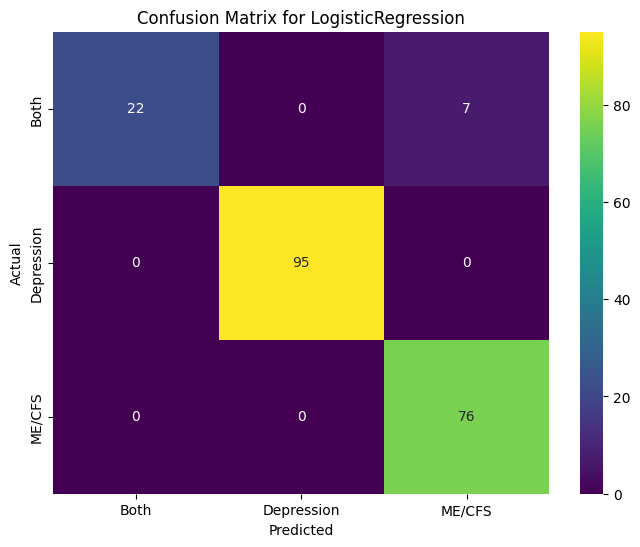

In [42]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state =43)

#normalize the data via standard scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#logistic reg try
classifier = LogisticRegression()
classifier.fit(X_train, y_train)
#perform predictions
y_pred = classifier.predict(X_test)

eval(y_test, y_pred, "LogisticRegression")

Accucary 0.990
Classification Report: 
               precision    recall  f1-score   support

         0.0       0.97      0.97      0.97        29
         1.0       1.00      1.00      1.00        95
         2.0       0.99      0.99      0.99        76

    accuracy                           0.99       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.99      0.99      0.99       200



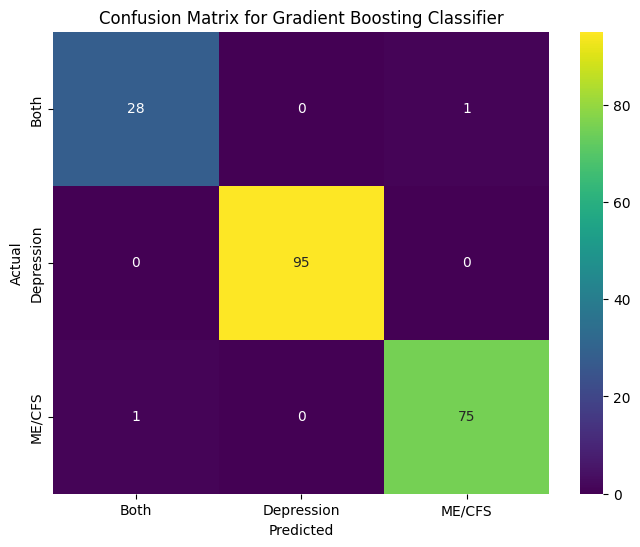

In [43]:
classifier2 = GradientBoostingClassifier()
classifier2.fit(X_train, y_train)
y_pred2 = classifier2.predict(X_test)

eval(y_test, y_pred2, "Gradient Boosting Classifier")